In [1]:
from models.vqvae_single import VQVAE_Single
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision

/home/clc/miniconda3/envs/var/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
from datasets.coco_lvis import LvisDataset

In [3]:
# 创建数据加载器
dataset = HQSeg44KTrainDataset(data_root='data/sam-hq')
# dataset = HQSeg44KTestDataset(data_root='data/sam-hq')

In [4]:
VOCAB_SIZE = 4096  # 码本大小
Z_CHANNELS = 32   # 潜在空间通道数
BASE_CHANNELS = 128  # 基础通道数
BETA = 0.25  # commitment loss权重
# DEVICE = torch.device(f'cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = 'cpu'

In [5]:
# torch.save(vqvae.state_dict(), 'ckpt/vqvae_single.pth')

In [5]:
from utils.metrics import calc_iou

def visualize(item):
    image, mask, instance_info = item

    mask = torch.from_numpy(mask)
    print(mask.shape)
    mask = mask.permute(2, 0, 1)
    mask = mask * 2 - 1

    # result = vqvae.img_to_reconstructed_img(mask.to(DEVICE).unsqueeze(0))
    indices = vqvae.img_to_idxBl(mask.to(DEVICE).unsqueeze(0))
    result = vqvae.idxBl_to_img(indices, same_shape=True)
    tokens = indices[-1].reshape(32, 32)
    print(len(indices), indices[-1].shape, tokens)
    channel_r = (tokens // 256)
    channel_g = (tokens // 16) % 16
    channel_b = tokens % 16
    token_map = torch.stack([channel_r, channel_b, channel_g]) / 16
    token_map = F.interpolate(token_map.unsqueeze(0), (256, 256), mode='nearest').squeeze(0)
    # result_conv = [edge(item) for item in result]
    logit = result[-1].squeeze(0).expand(3, -1, -1)
    chw = torchvision.utils.make_grid(torch.stack([(logit + 1) / 2, mask.to(DEVICE).expand(3, -1, -1), (logit > 0), token_map],), nrow=2, padding=1, pad_value=1.0)

    print(mask.shape, result[-1].shape)

    iou = calc_iou(result[-1], mask.to(DEVICE).unsqueeze(0))
    print(f'iou: {iou}')
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    print(chw.shape)
    chw = Image.fromarray(chw.astype(np.uint8))
    return chw

In [6]:
vqvae = VQVAE_Single(
    vocab_size=VOCAB_SIZE,
    z_channels=Z_CHANNELS,
    ch=BASE_CHANNELS,
    beta=BETA,
    v_patch_nums=(32,),
    test_mode=False,
    ddconfig=dict(in_channels=1, ch_mult=(1, 1, 2, 4), num_res_blocks=2,   # 通道数乘数，用于构建网络层
                using_sa=True, using_mid_sa=True,)
).to(DEVICE)

In [ ]:
checkpoint_path = 'ckpt/vqvae_single_monoscale_epoch_48.pth'
# vqvae.load_state_dict(torch.load('vae_ch160v4096z32.pth'))

vqvae.load_state_dict(torch.load(checkpoint_path, map_location='cpu')['model_state_dict'])

FileNotFoundError: [Errno 2] No such file or directory: 'ckpt/vqvae_single_monoscale_epoch_48.pth'

torch.Size([256, 256, 1])
1 torch.Size([1, 1024]) tensor([[2085, 2085, 2202,  ..., 2085, 2202,   50],
        [2085,  105, 1485,  ..., 2085, 2085, 2085],
        [2085,  105, 1485,  ..., 1485, 2085, 2085],
        ...,
        [3024, 3084,  638,  ..., 1485, 2085,  105],
        [1837, 1910, 2086,  ..., 1961,  315, 2085],
        [1485, 3183, 2379,  ..., 2165, 2085, 2961]])
torch.Size([1, 256, 256]) torch.Size([1, 1, 256, 256])
iou: tensor([0.9023])
(515, 515, 3)


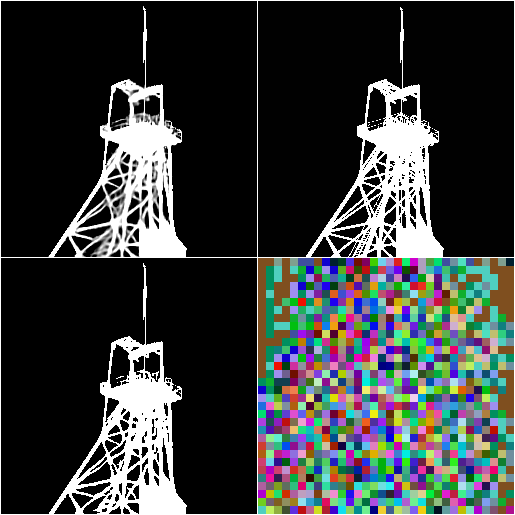

In [11]:
visualize(dataset[2333])